In [10]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


In [2]:
 %pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


In [7]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    accuracy_score,
    classification_report
)

# ==============================================================================
# BƯỚC 1 & 2: ĐỌC DỮ LIỆU VÀ TIỀN XỬ LÝ
# ==============================================================================
file_path = os.path.expanduser('~/Downloads/vgsales_cleaned.csv')
if not os.path.exists(file_path):
    file_path = 'C:/Users/LENOVO/Downloads/vgsales_cleaned.csv'

print(f"Đang đọc dữ liệu từ: {file_path}")
df = pd.read_csv(file_path)

# Gom nhóm các Publisher nhỏ (ít hơn 20 game) thành 'Other' để giảm bớt chiều dữ liệu
pub_counts = df['Publisher'].value_counts()
top_pubs = pub_counts[pub_counts >= 20].index
df['Publisher_Clean'] = df['Publisher'].apply(lambda x: x if x in top_pubs else 'Other')

# Tạo biến mục tiêu nhị phân: Is_Hit = 1 nếu Global_Sales >= 1.0 triệu bản
df['Is_Hit'] = (df['Global_Sales'] >= 1.0).astype(int)

# Chọn các thuộc tính dự đoán (Không dùng Rank và các cột Sales từng khu vực để tránh rò rỉ dữ liệu)
features = ['Platform', 'Genre', 'Publisher_Clean', 'Year']
X = df[features]
y = df['Is_Hit']

# Mã hóa One-Hot Encoding
X = pd.get_dummies(X, columns=['Platform', 'Genre', 'Publisher_Clean'], drop_first=True)

# ==============================================================================
# BƯỚC 3: CHIA TẬP TRAIN / TEST
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tổng số game: {len(df)} | Tập Train: {X_train.shape[0]} | Tập Test: {X_test.shape[0]}")
print(f"Tỷ lệ game Hit (Global_Sales >= 1M): {y.mean():.2%}\n")

# ==============================================================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH (BASELINE VS BALANCED)
# ==============================================================================
print("=" * 65)
print("1. MO HINH BASELINE (class_weight=None)")
print("=" * 65)
model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Recall (Phát hiện Game Hit): {recall_score(y_test, y_pred_base):.4f}")

print("\n" + "=" * 65)
print("2. MO HINH BALANCED (class_weight='balanced') - THEO TƯ DUY CAPSTONE")
print("=" * 65)
model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
model_bal.fit(X_train, y_train)
y_pred_bal = model_bal.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bal))
print(f"Accuracy:  {accuracy_score(y_test, y_pred_bal):.4f}")
print(f"Recall (Phát hiện Game Hit): {recall_score(y_test, y_pred_bal):.4f}")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred_bal))

# ==============================================================================
# BƯỚC 4.1: THRESHOLD TUNING (TINH CHỈNH NGƯỠNG QUYẾT ĐỊNH)
# ==============================================================================
print("=" * 65)
print("3. THRESHOLD TUNING (QUÉT CÁC NGƯỠNG DỰ ĐOÁN GAME HIT)")
print("=" * 65)

probs = model_bal.predict_proba(X_test)[:, 1]
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
results = []

for t in thresholds:
    y_pred_t = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    results.append({
        "Threshold": t,
        "Accuracy": round(float(accuracy_score(y_test, y_pred_t)), 4),
        "Recall (Hit)": round(float(recall_score(y_test, y_pred_t)), 4),
        "Precision": round(float(precision_score(y_test, y_pred_t)), 4),
        "Bỏ sót Game Hit (FN)": fn,
        "Báo động nhầm (FP)": fp,
    })

print(pd.DataFrame(results).to_string(index=False))

# ==============================================================================
# BƯỚC 5: DỰ ĐOÁN CHO MỘT TỰA GAME MỚI (INFERENCE PIPELINE)
# ==============================================================================
print("\n" + "=" * 65)
print("4. DỰ ĐOÁN KHẢ NĂNG THÀNH CÔNG CHO GAME MỚI")
print("=" * 65)

# Nhập thông tin thô của tựa game sắp phát hành
new_game_raw = pd.DataFrame([{
    "Platform": "PS4",
    "Genre": "Action",
    "Publisher_Clean": "Electronic Arts",
    "Year": 2024
}])

# Mã hóa và căn chỉnh khớp 100% cột với tập Train
new_game = pd.get_dummies(new_game_raw, columns=['Platform', 'Genre', 'Publisher_Clean'])
new_game = new_game.reindex(columns=X_train.columns, fill_value=0)

# Dự đoán xác suất đạt mốc 1 triệu bản
prob_hit = model_bal.predict_proba(new_game)[0][1]
print(f"Thông tin Game mới:\n{new_game_raw.to_string(index=False)}")
print(f"\n=> Xác suất Game này đạt mốc BOM TẤN (>= 1M bản): {prob_hit:.2%}")

Đang đọc dữ liệu từ: C:\Users\LENOVO/Downloads/vgsales_cleaned.csv
Tổng số game: 16598 | Tập Train: 13278 | Tập Test: 3320
Tỷ lệ game Hit (Global_Sales >= 1M): 12.54%

1. MO HINH BASELINE (class_weight=None)


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix:
[[2870   34]
 [ 373   43]]
Accuracy:  0.8774
Recall (Phát hiện Game Hit): 0.1034

2. MO HINH BALANCED (class_weight='balanced') - THEO TƯ DUY CAPSTONE
Confusion Matrix:
[[2112  792]
 [ 118  298]]
Accuracy:  0.7259
Recall (Phát hiện Game Hit): 0.7163

Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       0.95      0.73      0.82      2904
           1       0.27      0.72      0.40       416

    accuracy                           0.73      3320
   macro avg       0.61      0.72      0.61      3320
weighted avg       0.86      0.73      0.77      3320

3. THRESHOLD TUNING (QUÉT CÁC NGƯỠNG DỰ ĐOÁN GAME HIT)
 Threshold  Accuracy  Recall (Hit)  Precision  Bỏ sót Game Hit (FN)  Báo động nhầm (FP)
       0.5    0.7259        0.7163     0.2734                   118                 792
       0.4    0.6509        0.8341     0.2415                    69                1090
       0.3    0.5389        0.9135     0.2027                    36

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


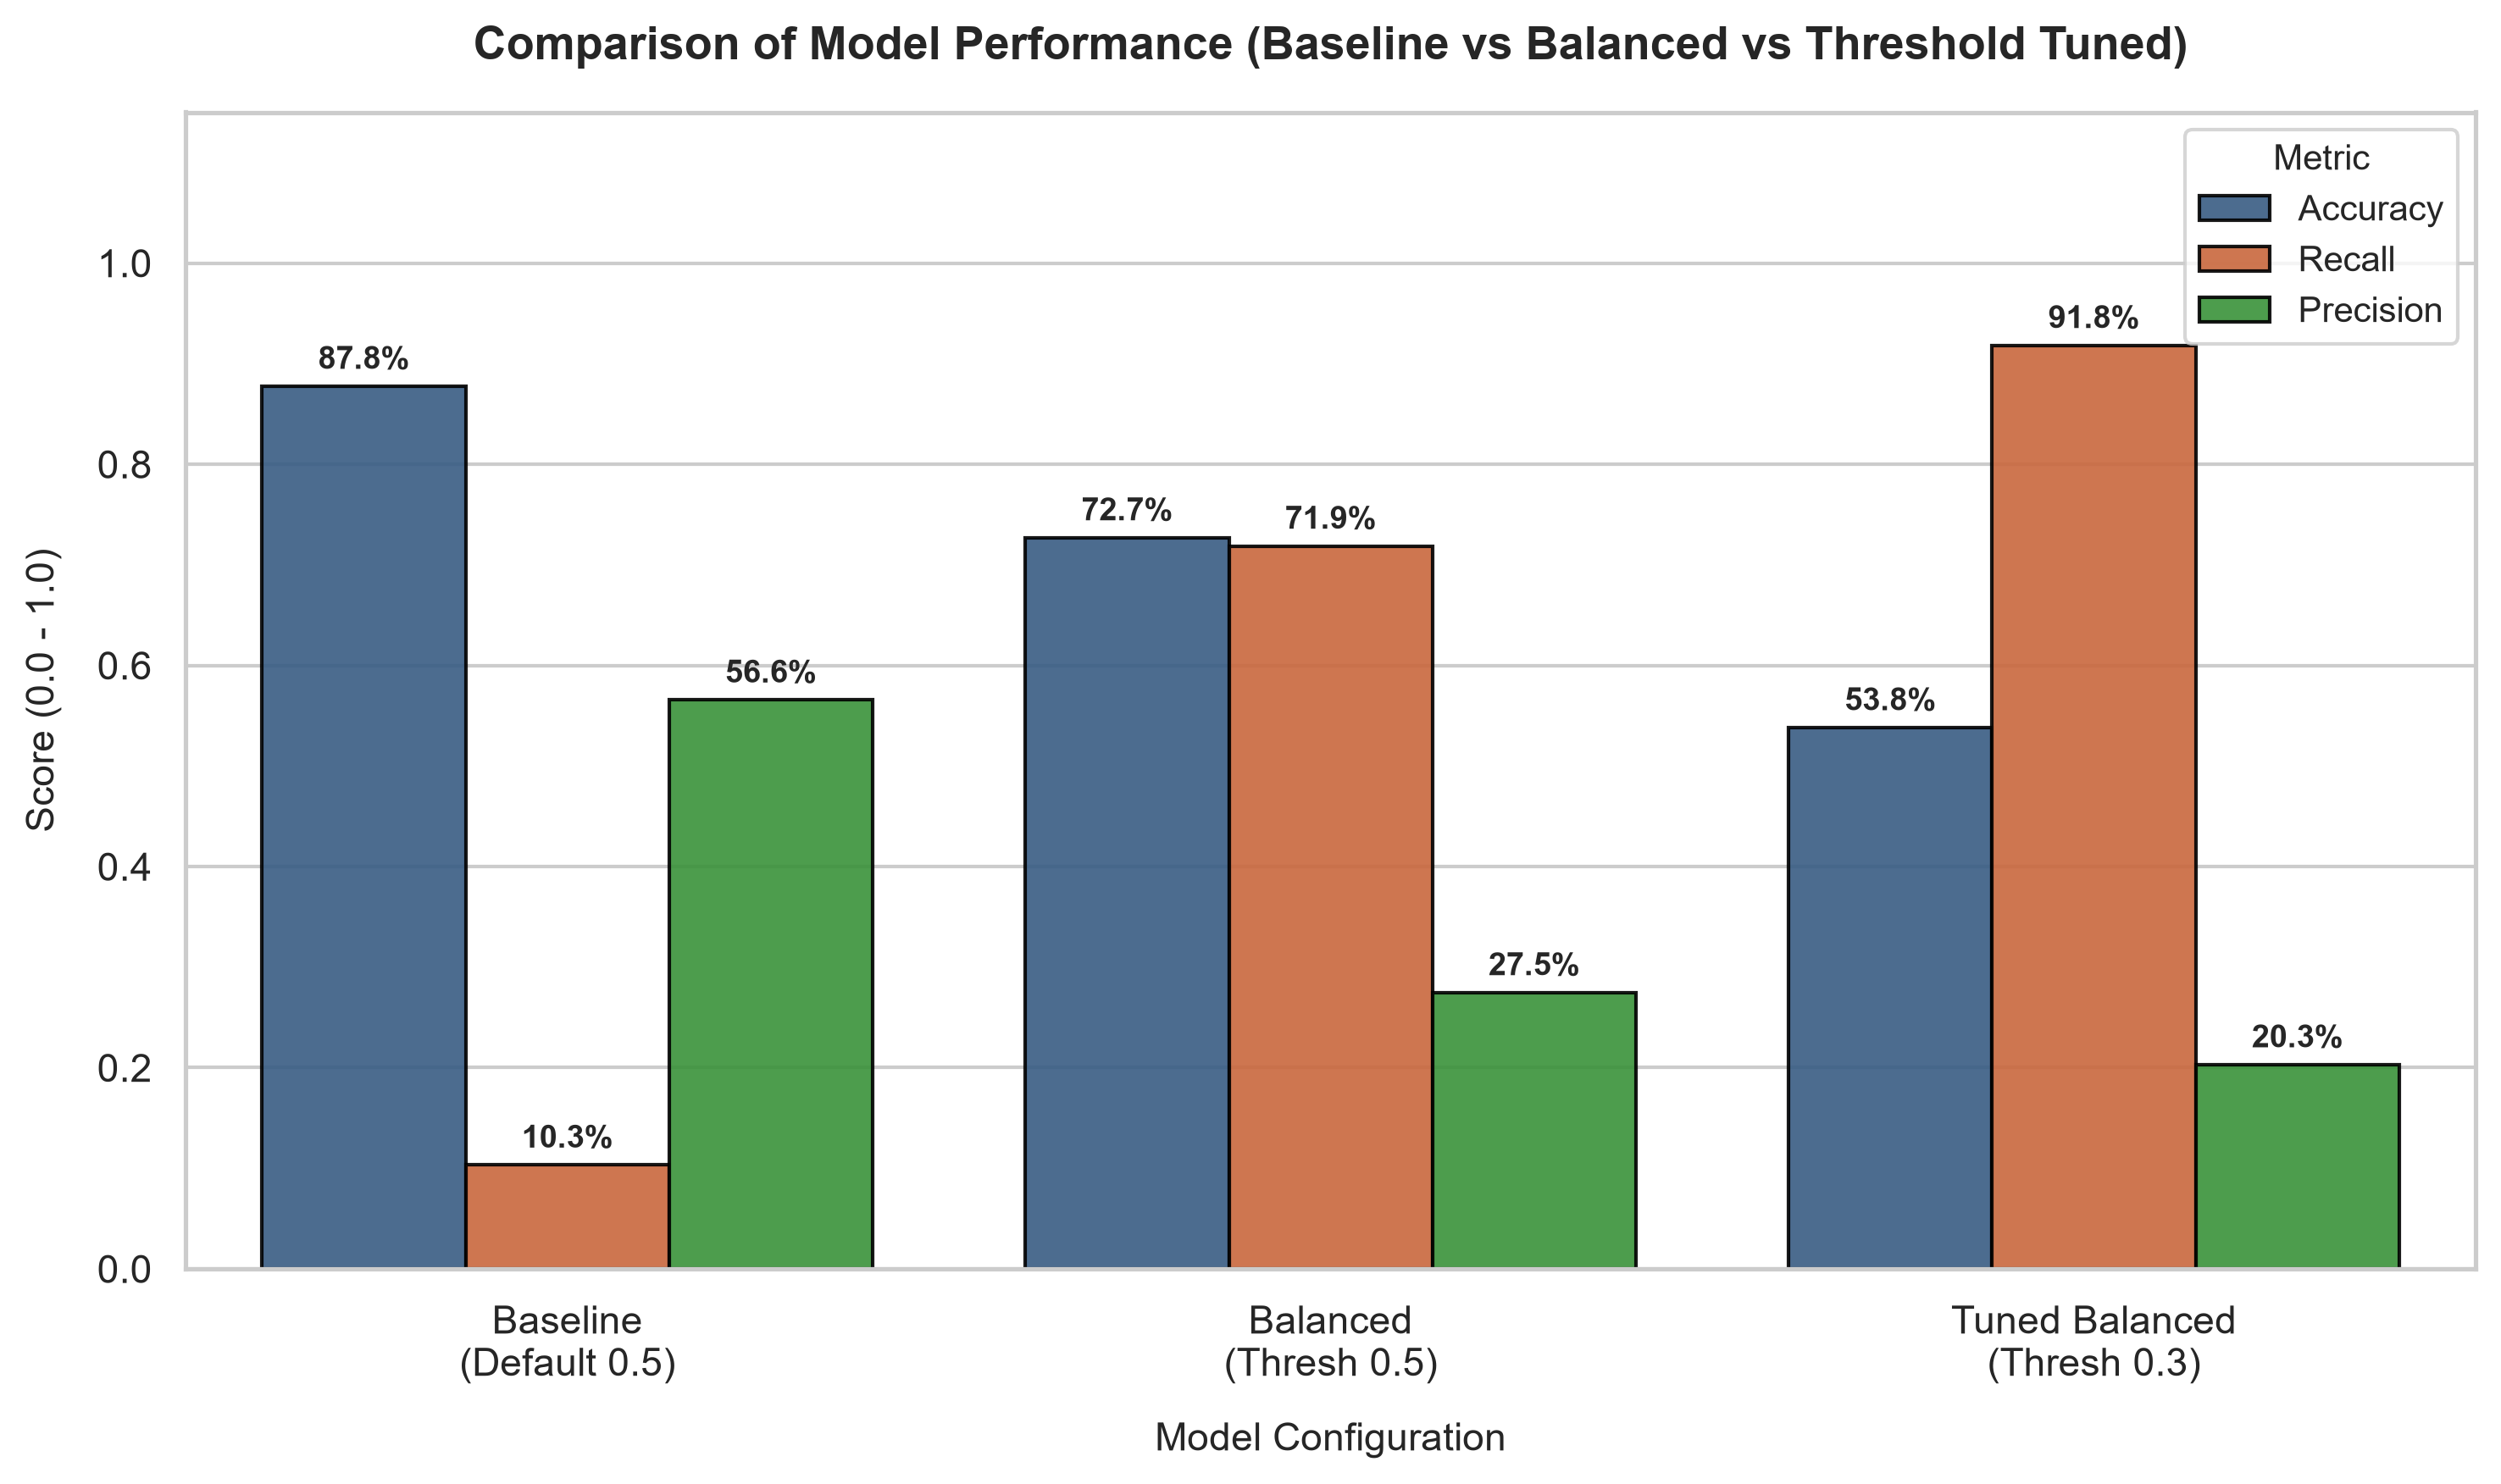

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, accuracy_score

# 1. Đọc dữ liệu vgsales_cleaned.csv
file_path = os.path.expanduser('~/Downloads/vgsales_cleaned.csv')
if not os.path.exists(file_path):
    file_path = 'C:/Users/LENOVO/Downloads/vgsales_cleaned.csv'

df = pd.read_csv(file_path)

# Tiền xử lý dữ liệu
pub_counts = df['Publisher'].value_counts()
top_pubs = pub_counts[pub_counts >= 20].index
df['Publisher_Clean'] = df['Publisher'].apply(lambda x: x if x in top_pubs else 'Other')
df['Is_Hit'] = (df['Global_Sales'] >= 1.0).astype(int)

features = ['Platform', 'Genre', 'Publisher_Clean', 'Year']
X = pd.get_dummies(df[features], columns=['Platform', 'Genre', 'Publisher_Clean'], drop_first=True)
y = df['Is_Hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Huấn luyện 3 cấu hình mô hình
# Cấu hình 1: Baseline
m_base = LogisticRegression(max_iter=3000)
m_base.fit(X_train, y_train)
y_pred_base = m_base.predict(X_test)

# Cấu hình 2: Balanced (Threshold 0.5)
m_bal = LogisticRegression(max_iter=3000, class_weight='balanced')
m_bal.fit(X_train, y_train)
y_pred_bal = m_bal.predict(X_test)

# Cấu hình 3: Tuned Balanced (Threshold 0.3)
probs = m_bal.predict_proba(X_test)[:, 1]
y_pred_tuned = (probs >= 0.3).astype(int)

# 3. Tạo DataFrame tổng hợp kết quả
data = [
    {
        'Model': 'Baseline\n(Default 0.5)',
        'Accuracy': accuracy_score(y_test, y_pred_base),
        'Recall': recall_score(y_test, y_pred_base),
        'Precision': precision_score(y_test, y_pred_base)
    },
    {
        'Model': 'Balanced\n(Thresh 0.5)',
        'Accuracy': accuracy_score(y_test, y_pred_bal),
        'Recall': recall_score(y_test, y_pred_bal),
        'Precision': precision_score(y_test, y_pred_bal)
    },
    {
        'Model': 'Tuned Balanced\n(Thresh 0.3)',
        'Accuracy': accuracy_score(y_test, y_pred_tuned),
        'Recall': recall_score(y_test, y_pred_tuned),
        'Precision': precision_score(y_test, y_pred_tuned, zero_division=0)
    }
]

df_metrics = pd.DataFrame(data)
df_melted = pd.melt(df_metrics, id_vars=['Model'], var_name='Metric', value_name='Score')

# 4. Vẽ biểu đồ cột (Grouped Bar Chart)
plt.figure(figsize=(10, 6), dpi=300)
sns.set_theme(style='whitegrid')

# Bảng màu đại diện cho 3 chỉ số
palette = {'Accuracy': '#2b5c8f', 'Recall': '#e05d26', 'Precision': '#2ca02c'}

ax = sns.barplot(
    data=df_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette=palette,
    edgecolor='black',
    alpha=0.9
)

plt.title('Comparison of Model Performance (Baseline vs Balanced vs Threshold Tuned)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Model Configuration', fontsize=11, labelpad=10)
plt.ylabel('Score (0.0 - 1.0)', fontsize=11, labelpad=10)
plt.ylim(0, 1.15)
plt.legend(title='Metric', title_fontsize='10', fontsize='10', loc='upper right')

# Hiển thị phần trăm % trên từng cột
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f'{height:.1%}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )

plt.tight_layout()
plt.show()